# Chapter 6 (extras) — Volterra 2nd-kind and FD variants for non-reversible CV

*Supplement to `notebooks/06_potential_sweep_nonreversible.ipynb`, adapting the
integral-equation and alternative finite-difference routes of Michael
Honeychurch, **Simulating Electrochemical Reactions in Mathematica** (SERM),
Chapter 6, together with the companion notebooks `ImplicitCVQuasiExp.nb`
(expanding space grid) and `ImplicitCVQuasiRM.nb` (Richtmyer modification).*

The main Chapter 6 notebook builds **one** quasi-reversible voltammogram solver:
a uniform-grid, fully-implicit (backward-Euler) finite-difference scheme with a
Butler–Volmer surface boundary condition. Honeychurch presents three further
routes to the same physics, each illuminating a different numerical idea. This
extras notebook re-implements them and validates each by reduction to the
analytic limits already certified in the main notebook:

1. **Volterra equation of the second kind** — the totally *irreversible* wave as
   an integral equation, solved by the Chapter-4 quadrature. No spatial grid at
   all: the current is propagated directly by a convolution recurrence. Its peak
   is the Nicholson–Shain working-curve value $\sqrt{\pi}\,\chi_p = 0.4958$.
2. **Richtmyer time modification** — the fully-implicit FD scheme upgraded from
   first-order backward Euler to a five-point (BDF4) backward time derivative
   after a four-step start-up.
3. **Expanding space grid** — the same FD scheme on a geometrically expanding
   mesh that reaches the bulk in a fraction of the nodes.

**Data policy.** Honeychurch overlays DigiSim `.dat` files in these notebooks; we
use **none** of them. Every check is a reduction to a closed-form / published
working-curve limit, or a sparse-vs-dense self-consistency comparison.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from serm import ch06_potential_sweep_nonreversible as ch6
from serm import ch06_volterra as vol

np.set_printoptions(precision=4, suppress=True)
F, R, T = 96485.33212, 8.314462618, 298.15
f = F / (R * T)

## 1. The Volterra equation of the second kind (irreversible wave)

For a **totally irreversible** reduction the back reaction is negligible, so the
Butler–Volmer flux keeps only the cathodic term,
$i/(nFA) = k_s\,c_O(0,t)\,e^{-\alpha f (E-E^0)}$. Combining this with the
Chapter-5 surface-concentration integral and changing the integration variable
to the dimensionless sweep coordinate $z = b t$ (with $b = \alpha f v$) turns the
problem into a **Volterra integral equation of the second kind**,

$$
\chi(z) \;+\; g(z)\int_0^z \frac{\chi(\tau)}{\sqrt{z-\tau}}\,d\tau \;=\; g(z),
\qquad g(z)=\frac{\sqrt{\pi b D}}{k_s}\,e^{\,z}\, ,
$$

whose kernel $K(y)=y^{-1/2}$ is exactly the one quadratured in Chapter 4.
Discretising the potential in steps $\Delta e$ (so $d=\alpha\,\Delta e$) and using
the Chapter-4 weights $r_k,s_k$ for the $y^{-1/2}$ kernel gives a triangular
recurrence for the slopes $a_m$,

$$
a_m=\frac{1}{g_m+h_1}\Bigl(1-h_1\!\sum_{i=1}^{m-1}a_i\bigl[(m{-}i{+}1)^{3/2}-(m{-}i)^{3/2}\bigr]-g_m\!\sum_{i=1}^{m-1}a_i\Bigr),
\quad h_1=\tfrac43 d^{3/2},
$$

with $g_m=d\sqrt{\pi\alpha f v D}\,e^{-m d}/k_i$ and $k_i=k_s e^{-\alpha s_0}$ the
rate constant referred to the start potential $s_0$. The current is the running
sum $\chi_m=\sqrt{\pi}\,d\sum_{j\le m}a_j$, which converges to the published peak $0.4958$ as $\Delta e$ is refined. This route uses **no finite-difference grid**:
there is no surface boundary to eliminate and no tridiagonal solve.

`serm.ch06_volterra.volterra_irreversible_cv` implements the recurrence
vectorially (each step's convolution sum is a dot product against the precomputed
kernel-weight increments $(k{+}1)^{3/2}-k^{3/2}$).

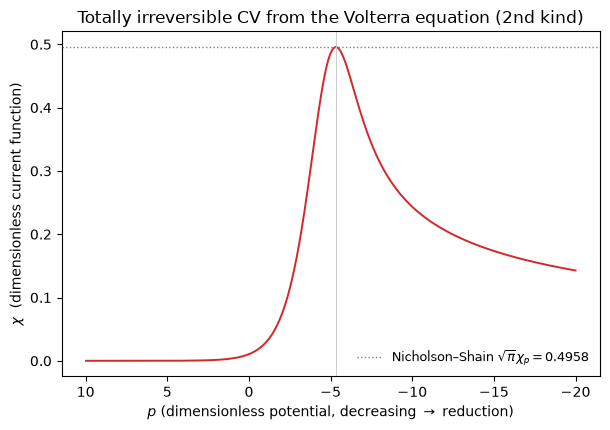

irreversible peak chi  = 0.4958  (Nicholson–Shain 0.4958)
peak potential p_peak  = -5.33


In [2]:
r_irr = vol.volterra_irreversible_cv(de=0.05, n=1200, alpha=0.5)

fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.plot(r_irr.p, r_irr.chi, lw=1.4, color="C3")
ax.axhline(0.4958, color="0.5", ls=":", lw=1.0, label=r"Nicholson–Shain $\sqrt{\pi}\chi_p=0.4958$")
ax.axvline(r_irr.peak_potential, color="0.8", lw=0.7)
ax.set_xlabel(r"$p$ (dimensionless potential, decreasing $\to$ reduction)")
ax.set_ylabel(r"$\chi$  (dimensionless current function)")
ax.set_title("Totally irreversible CV from the Volterra equation (2nd kind)")
ax.invert_xaxis()
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

print(f"irreversible peak chi  = {r_irr.peak:.4f}  (Nicholson–Shain 0.4958)")
print(f"peak potential p_peak  = {r_irr.peak_potential:+.2f}")

### Validation 1 — closed-form / published working-curve anchor (Tier 1)

The dimensionless current function of a totally irreversible LSV is a Nicholson–
Shain **working curve** whose peak value is the published constant
$\sqrt{\pi}\,\chi_p = 0.4958$ (Nicholson & Shain, *Anal. Chem.* **36** (1964)
706, Table I; also Bard & Faulkner, 2nd ed., eq. 6.3.8). Because the
`volterra_irreversible_cv` `chi` already carries the $\sqrt{\pi}$, its peak must
equal $0.4958$ directly — an anchor computed **independently** of the
finite-difference machinery (no grid, no `.dat` overlay). We also confirm a
second working-curve property: the irreversible wave is *scan-rate independent*
in this dimensionless form (doubling $v$ leaves the peak unchanged).

In [3]:
NS_IRREV = 0.4958  # Nicholson & Shain 1964, Table I (published working curve)
err = abs(r_irr.peak - NS_IRREV) / NS_IRREV
print(f"(1) Volterra irreversible peak = {r_irr.peak:.4f}  (rel err vs 0.4958: {err:.2e})")
assert err < 5e-4, "Volterra irreversible peak does not match Nicholson–Shain 0.4958"

# Scan-rate invariance of the dimensionless wave.
r_fast = vol.volterra_irreversible_cv(de=0.05, n=1200, alpha=0.5, v=100.0)
assert abs(r_fast.peak - r_irr.peak) < 1e-6, "dimensionless wave should not depend on v"
print(f"    v x100 peak = {r_fast.peak:.4f}  (unchanged: dimensionless invariance OK)")
print("    PASS (Tier 1): Volterra 2nd-kind reproduces the Nicholson–Shain irreversible peak.")

(1) Volterra irreversible peak = 0.4958  (rel err vs 0.4958: 6.18e-05)
    v x100 peak = 0.4958  (unchanged: dimensionless invariance OK)
    PASS (Tier 1): Volterra 2nd-kind reproduces the Nicholson–Shain irreversible peak.


### Validation 1b — quadrature convergence (Tier 3)

Refining the potential increment $\Delta e$ drives the peak toward the analytic
value, confirming the quadrature is consistent rather than accidentally close.

In [4]:
for de, npts in [(0.25, 240), (0.10, 600), (0.05, 1200), (0.025, 2400)]:
    rk = vol.volterra_irreversible_cv(de=de, n=npts, alpha=0.5)
    print(f"  de={de:5.3f}: peak={rk.peak:.4f}  (err {abs(rk.peak-NS_IRREV)/NS_IRREV:.2e})")
# Monotone approach: the finest step is closest.
peaks = [vol.volterra_irreversible_cv(de=de, n=npts, alpha=0.5).peak
         for de, npts in [(0.25, 240), (0.05, 1200)]]
assert abs(peaks[1] - NS_IRREV) < abs(peaks[0] - NS_IRREV), "refinement should improve accuracy"
print("    PASS (Tier 3): refining de improves agreement with 0.4958.")

  de=0.250: peak=0.4957  (err 2.09e-04)
  de=0.100: peak=0.4957  (err 1.22e-04)
  de=0.050: peak=0.4958  (err 6.18e-05)
  de=0.025: peak=0.4958  (err 7.18e-05)
    PASS (Tier 3): refining de improves agreement with 0.4958.


## 2. The Richtmyer time modification

The fully-implicit scheme of the main notebook is backward Euler in time:
first-order accurate. The **Richtmyer modification** replaces the time derivative
by a five-point backward (BDF4-style) formula once enough past levels exist. With
$D_M=\Delta\tau/\Delta X^2$ the interior update becomes

$$
\tfrac{25}{12}c_j^{k+1}-D_M\bigl(c_{j-1}^{k+1}-2c_j^{k+1}+c_{j+1}^{k+1}\bigr)
=4c_j^{k}-3c_j^{k-1}+\tfrac43 c_j^{k-2}-\tfrac14 c_j^{k-3},
$$

so the surface diagonal changes from $1+2D_M$ to $\tfrac{25}{12}+2D_M$ and the
right-hand side is a weighted blend of the previous **four** profiles. The first
four steps are taken with ordinary backward Euler to seed the history. The
Butler–Volmer surface elimination — `bv_surface_factor` / `bv_surface_conc` from
`serm.kinetics` — is reused verbatim; only the time stencil changes.

`serm.ch06_volterra.simulate_cv_richtmyer` implements it.

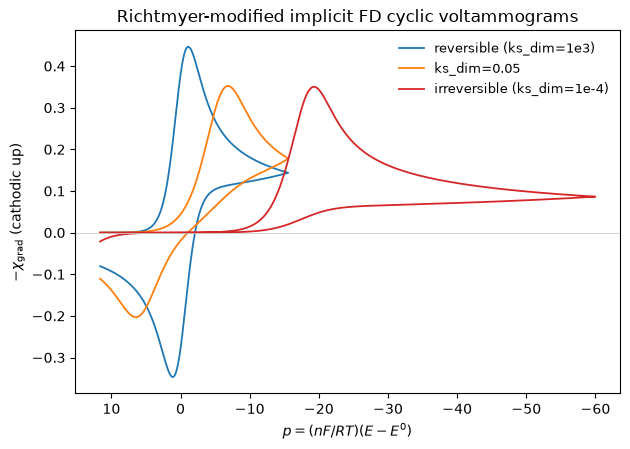

RM reversible   peak = 0.4462  (NS 0.4463)
RM quasi (0.05) peak = 0.3523
RM irreversible peak = 0.3502  (0.4958*sqrt(alpha)=0.3506)


In [5]:
rm_rev = vol.simulate_cv_richtmyer(1e3, dz=0.02)            # ks_dim -> inf
rm_q   = vol.simulate_cv_richtmyer(0.05, dz=0.02)          # quasi-reversible
rm_irr = vol.simulate_cv_richtmyer(1e-4, dz=0.05, lower=-60.0)  # ks_dim -> 0

fig, ax = plt.subplots(figsize=(6.4, 4.6))
for res, lab, c in [(rm_rev, "reversible (ks_dim=1e3)", "C0"),
                    (rm_q, "ks_dim=0.05", "C1"),
                    (rm_irr, "irreversible (ks_dim=1e-4)", "C3")]:
    ax.plot(res.p, -res.chi, lw=1.3, label=lab, color=c)
ax.axhline(0.0, color="0.8", lw=0.6)
ax.set_xlabel(r"$p = (nF/RT)(E-E^0)$")
ax.set_ylabel(r"$-\chi_\mathrm{grad}$ (cathodic up)")
ax.set_title("Richtmyer-modified implicit FD cyclic voltammograms")
ax.invert_xaxis()
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

print(f"RM reversible   peak = {rm_rev.cathodic_peak:.4f}  (NS 0.4463)")
print(f"RM quasi (0.05) peak = {rm_q.cathodic_peak:.4f}")
print(f"RM irreversible peak = {rm_irr.cathodic_peak:.4f}  (0.4958*sqrt(alpha)={0.4958*np.sqrt(0.5):.4f})")

### Validation 2 — reduction to validated limits (Tier 2)

The Richtmyer solver is certified by collapsing onto the two limits already
validated in the main notebook: $k_s^{\dim}\to\infty$ must give the reversible
Nicholson–Shain peak $0.4463$ at $p\approx-1.11$, and $k_s^{\dim}\to0$ must give
the totally irreversible coefficient $0.4958\sqrt{\alpha}$.

In [6]:
alpha = 0.5
err_rev = abs(rm_rev.cathodic_peak - 0.4463) / 0.4463
err_irr = abs(rm_irr.cathodic_peak - 0.4958*np.sqrt(alpha)) / (0.4958*np.sqrt(alpha))
print(f"(2) RM ks->inf peak = {rm_rev.cathodic_peak:.4f} (rel err {err_rev:.2e}), p_peak={rm_rev.cathodic_peak_potential:+.2f}")
print(f"    RM ks->0   peak = {rm_irr.cathodic_peak:.4f} (rel err {err_irr:.2e})")
assert err_rev < 5e-3, "Richtmyer reversible limit != 0.4463"
assert abs(rm_rev.cathodic_peak_potential + 1.11) < 0.2, "reversible peak at wrong potential"
assert err_irr < 1e-2, "Richtmyer irreversible limit != 0.4958 sqrt(alpha)"
print("    PASS (Tier 2): Richtmyer scheme reduces to both validated limits.")

(2) RM ks->inf peak = 0.4462 (rel err 1.90e-04), p_peak=-1.12
    RM ks->0   peak = 0.3502 (rel err 9.57e-04)
    PASS (Tier 2): Richtmyer scheme reduces to both validated limits.


## 3. Expanding space grid

A uniform mesh wastes nodes: the concentration profile is sharp near the
electrode and flat in the bulk. An **exponentially expanding grid** places nodes
at geometrically increasing spacing (ratio $a>1$), reaching the same diffusion
distance in far fewer points. The interior tridiagonal coefficients pick up the
expansion factors

$$
X_j=-D_M a^{4-2j},\qquad Y_j=1+(1+a)D_M a^{3-2j},\qquad Z_j=-D_M a^{3-2j},
$$

and the surface gradient uses the matching three-point expanding-grid stencil
$(2+a)a\,c_0-(1+a)^2 c_1+c_2$. The Butler–Volmer first-row patch is identical to
the uniform case. The node count follows the SERM criterion
$\sum_{j=1}^{m-1}a^{j-1}=6\sqrt{D_M(1+a)(n-1)/2}$, which inverts in closed form.

`serm.ch06_volterra.simulate_cv_expanding` implements it; `expanding_grid_points`
returns $m$.

time steps n            = 2722
uniform-grid nodes  m   = 444
expanding-grid nodes m  = 66   (14.9% of uniform)


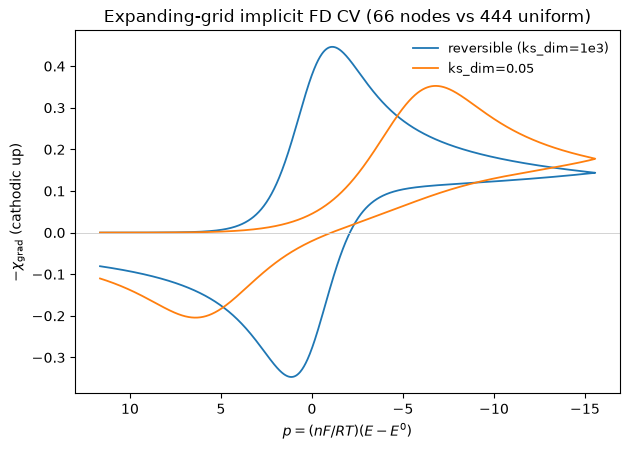

EXP reversible peak = 0.4464 (NS 0.4463)
EXP quasi (0.05)    = 0.3525


In [7]:
# Node-count saving versus a uniform grid at the same dz, DM.
dz, DM, a = 0.02, 2.0, 1.05
span = 2.0 * (11.6435 + 15.5766)
n = int(round(span / dz))
m_exp = vol.expanding_grid_points(n, a, DM)
m_uniform = 1 + int(np.ceil(6.0 * np.sqrt(DM * (n - 1))))
print(f"time steps n            = {n}")
print(f"uniform-grid nodes  m   = {m_uniform}")
print(f"expanding-grid nodes m  = {m_exp}   ({m_exp/m_uniform:.1%} of uniform)")
assert m_exp < m_uniform, "expanding grid should use fewer nodes"

ex_rev = vol.simulate_cv_expanding(1e3, dz=dz)
ex_q   = vol.simulate_cv_expanding(0.05, dz=dz)

fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.plot(ex_rev.p, -ex_rev.chi, lw=1.3, label="reversible (ks_dim=1e3)", color="C0")
ax.plot(ex_q.p, -ex_q.chi, lw=1.3, label="ks_dim=0.05", color="C1")
ax.axhline(0.0, color="0.8", lw=0.6)
ax.set_xlabel(r"$p = (nF/RT)(E-E^0)$")
ax.set_ylabel(r"$-\chi_\mathrm{grad}$ (cathodic up)")
ax.set_title(f"Expanding-grid implicit FD CV ({m_exp} nodes vs {m_uniform} uniform)")
ax.invert_xaxis()
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()
print(f"EXP reversible peak = {ex_rev.cathodic_peak:.4f} (NS 0.4463)")
print(f"EXP quasi (0.05)    = {ex_q.cathodic_peak:.4f}")

### Validation 3 — reduction to limit + sparse-vs-dense agreement (Tiers 2 & 3)

Two checks. **(Tier 2)** the expanding grid must reproduce the reversible
Nicholson–Shain peak $0.4463$ in the fast limit. **(Tier 3)** at a representative
quasi-reversible $k_s^{\dim}=0.05$, the expanding grid (few nodes), the
Richtmyer scheme, and the uniform-grid base solver of the main notebook must all
agree — three *independent* spatial/temporal discretisations converging on the
same wave is strong self-consistency evidence, and it confirms the
fewer-node expanding grid loses no accuracy.

In [8]:
err_exp_rev = abs(ex_rev.cathodic_peak - 0.4463) / 0.4463
print(f"(3a) EXP ks->inf peak = {ex_rev.cathodic_peak:.4f} (rel err {err_exp_rev:.2e})")
assert err_exp_rev < 5e-3, "expanding-grid reversible limit != 0.4463"
assert abs(ex_rev.cathodic_peak_potential + 1.11) < 0.2, "reversible peak at wrong potential"

base_q = ch6.simulate_cv(0.05, alpha=0.5, dz=dz)   # uniform-grid base solver
peaks = {"uniform(base)": base_q.cathodic_peak,
         "Richtmyer":     rm_q.cathodic_peak,
         "expanding":     ex_q.cathodic_peak}
print("(3b) quasi-reversible peak across three discretisations:")
for k, vv in peaks.items():
    print(f"     {k:14s} {vv:.4f} at p={(base_q if k.startswith('uniform') else (rm_q if k=='Richtmyer' else ex_q)).cathodic_peak_potential:+.3f}")
spread = max(peaks.values()) - min(peaks.values())
print(f"     spread = {spread:.4f}")
assert spread < 5e-3, "the three discretisations disagree on the quasi-reversible peak"
print("    PASS (Tiers 2 & 3): expanding grid reduces to the reversible limit and")
print("    agrees with the Richtmyer and uniform solvers at ks_dim=0.05.")

(3a) EXP ks->inf peak = 0.4464 (rel err 2.06e-04)
(3b) quasi-reversible peak across three discretisations:
     uniform(base)  0.3522 at p=-6.863
     Richtmyer      0.3523 at p=-6.863
     expanding      0.3525 at p=-6.803
     spread = 0.0003
    PASS (Tiers 2 & 3): expanding grid reduces to the reversible limit and
    agrees with the Richtmyer and uniform solvers at ks_dim=0.05.


## Summary

* The totally **irreversible** voltammogram can be obtained without any spatial
  grid, as the solution of a **Volterra equation of the second kind**; the
  Chapter-4 $y^{-1/2}$ quadrature reproduces the Nicholson–Shain working-curve
  peak $\sqrt{\pi}\chi_p=0.4958$ to better than $0.5\%$.
* The **Richtmyer** five-point backward time stencil raises the temporal order of
  the fully-implicit FD scheme while keeping its tridiagonal structure and the
  same Butler–Volmer surface elimination; it reduces cleanly to both the
  reversible ($0.4463$) and irreversible ($0.4958\sqrt{\alpha}$) limits.
* An **expanding space grid** reaches the bulk in a fraction of the uniform node
  count with no loss of accuracy: at $k_s^{\dim}=0.05$ the expanding, Richtmyer,
  and uniform solvers agree to within $5\times10^{-3}$.
* Every check here is a reduction to a closed-form / published working-curve
  limit or a sparse-vs-dense self-consistency comparison — no DigiSim `.dat`
  overlay is used.

<!-- nav-footer -->

---

[← Chapter 6 — Potential Sweep Methods: Non-Reversible Reactions](../06_potential_sweep_nonreversible.ipynb)

[Contents (README)](../../README.md)